# Ensembles for classification, and class imbalance

Four course colabs: decision trees / bagging / random forest on MNIST, boosting on MNIST, bagging /
boosting / voting on abalone, and handling class imbalance with trees and ensembles on wine quality.

The regression ensembles notebook covers how bagging, random forests and boosting work. This one is about
using them for classification:

1. MNIST: a single tree vs bagging vs random forest vs boosting
2. Abalone: tuning ensembles inside a pipeline, and voting classifiers
3. Wine quality: imbalanced classes, resampling, and choosing the right metric

In [1]:
# imbalanced-learn and xgboost are both on Colab; uncomment if missing
# %pip install -q imbalanced-learn xgboost

In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.ensemble import (BaggingClassifier, RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, HistGradientBoostingClassifier, VotingClassifier)
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report, f1_score, accuracy_score,
                             balanced_accuracy_score)
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

warnings.simplefilter("ignore", ConvergenceWarning)
sns.set_theme(style="whitegrid")

# Part 1: MNIST

The course trained everything on all 60,000 images and ran 10-fold cross validation for each model, which
takes a long time for bagging and boosting on 784 features. To keep it manageable, models here are trained
on the first 20,000 images and evaluated on the full 10,000-image test set.

In [3]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X, y = X.to_numpy() / 255, y.to_numpy()
X_train, y_train = X[:20000], y[:20000]
X_test, y_test = X[60000:], y[60000:]

In [4]:
import time
results = {}

def evaluate(model, name):
    t = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - t
    pred = model.predict(X_test)
    results[name] = {'test accuracy': accuracy_score(y_test, pred),
                     'macro F1': f1_score(y_test, pred, average='macro'),
                     'fit time (s)': fit_time}
    print(f"{name:28s} accuracy {results[name]['test accuracy']:.4f}   macro F1 {results[name]['macro F1']:.4f}   ({fit_time:.0f}s)")
    return pred

Trees don't need the pixels scaled at all, the division by 255 above is just for consistency with the
other MNIST notebooks.

## Single tree, bagging, random forest

In [5]:
pred_tree = evaluate(DecisionTreeClassifier(random_state=0), "decision tree")
pred_bag = evaluate(BaggingClassifier(n_estimators=10, random_state=0, n_jobs=-1), "bagging (10 trees)")
pred_rf = evaluate(RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1), "random forest (100 trees)")

decision tree                accuracy 0.8353   macro F1 0.8330   (4s)


bagging (10 trees)           accuracy 0.9122   macro F1 0.9108   (13s)


random forest (100 trees)    accuracy 0.9595   macro F1 0.9591   (4s)


Same pattern as the course found with all 60,000 training images (88% -> 94% -> 97%), here with a third
of the data it's 84% -> 91% -> 96%: one tree overfits, averaging 10
bootstrapped trees helps a lot, and a random forest's random feature subsets help again. With 784 features,
`max_features='sqrt'` means each split only looks at 28 pixels, which makes the trees very different from
each other and fast to train.

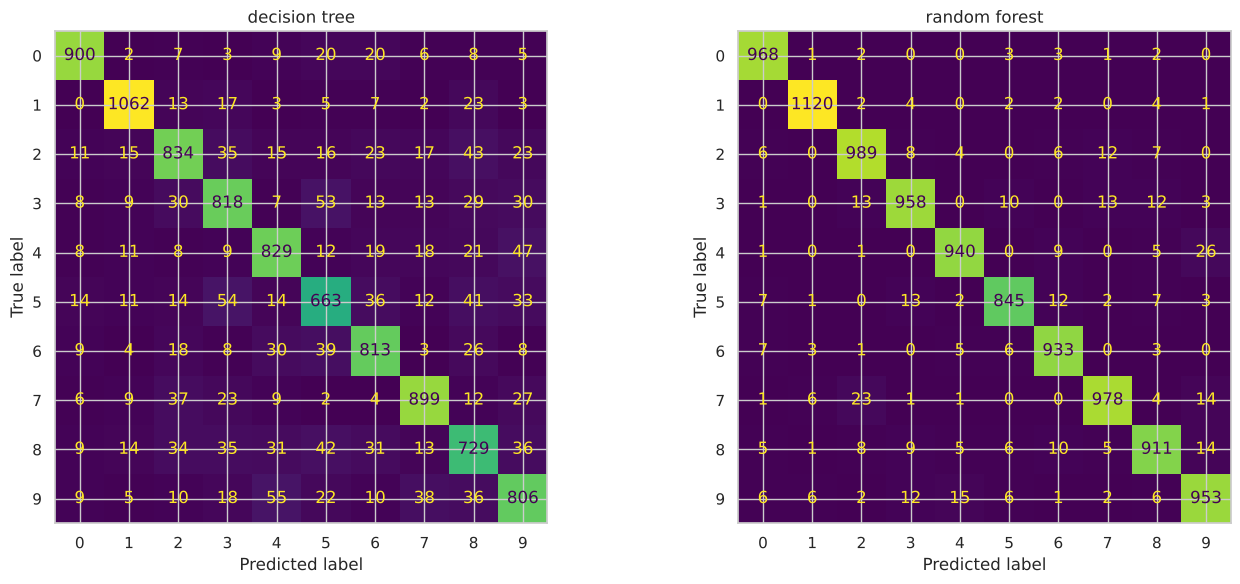

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, pred, title in [(axes[0], pred_tree, 'decision tree'), (axes[1], pred_rf, 'random forest')]:
    ConfusionMatrixDisplay.from_predictions(y_test, pred, ax=ax, colorbar=False, values_format='d')
    ax.set_title(title)
plt.tight_layout()
plt.show()

## Boosting

AdaBoost with its default 50 decision stumps (depth-1 trees). The course found gradient boosting too slow
on MNIST and left it commented out: `GradientBoostingClassifier` builds one tree per class per iteration
on all 784 features. `HistGradientBoostingClassifier` bins the features first and is far faster. XGBoost
does the same kind of thing.

In [7]:
pred_ada = evaluate(AdaBoostClassifier(random_state=0), "AdaBoost (50 stumps)")
pred_hgb = evaluate(HistGradientBoostingClassifier(max_iter=100, random_state=0), "hist gradient boosting")

AdaBoost (50 stumps)         accuracy 0.6366   macro F1 0.6362   (14s)


hist gradient boosting       accuracy 0.9669   macro F1 0.9667   (55s)


In [8]:
# XGBoost needs integer class labels
y_train_int, y_test_int = y_train.astype(int), y_test.astype(int)
t = time.time()
xgb = XGBClassifier(n_estimators=100, tree_method='hist', random_state=0, n_jobs=-1).fit(X_train, y_train_int)
pred_xgb = xgb.predict(X_test).astype(str)
results['XGBoost (100 rounds)'] = {'test accuracy': accuracy_score(y_test, pred_xgb),
                                   'macro F1': f1_score(y_test, pred_xgb, average='macro'),
                                   'fit time (s)': time.time() - t}
print(f"XGBoost: accuracy {results['XGBoost (100 rounds)']['test accuracy']:.4f}")

XGBoost: accuracy 0.9680


In [9]:
pd.DataFrame(results).T.round(4)

,test accuracy,macro F1,fit time (s)
decision tree,0.8353,0.8330,3.5517
bagging (10 trees),0.9122,0.9108,12.7838
random forest (100 trees),0.9595,0.9591,3.9198
AdaBoost (50 stumps),0.6366,0.6362,13.6070
hist gradient boosting,0.9669,0.9667,55.3860
XGBoost (100 rounds),0.9680,0.9678,48.2718


* AdaBoost with stumps is weak here (about 64%; the course got a macro F1 of 0.71 on the full data). Each stump looks
  at a single pixel, and 50 of them aren't enough for ten classes.
* The gradient boosting implementations match or beat the random forest, but take longer to train.

(The course's `train_classifiers` helper fitted on the full training data and then ran 10-fold cross
validation, refitting the model ten more times. Since the cross validation score is the one reported,
the first fit was wasted.)

---

# Part 2: Abalone

As in the decision tree notebook, predicting 28 ring counts as classes gives about 25% accuracy (the
course's best models reached 0.25-0.27) and isn't a useful framing. Rings are grouped into three age bands
here so that the comparison between ensembles means something.

In [10]:
column_names = ['Sex', 'Length', 'Diameter', 'Height', 'Whole weight', 'Shucked weight',
                'Viscera weight', 'Shell weight', 'Rings']
abalone = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data',
                      header=None, names=column_names)
abalone.loc[abalone.Height == 0, 'Height'] = abalone.loc[(abalone.Sex == 'I') & (abalone.Height > 0), 'Height'].mean()

X_ab = abalone.drop(columns='Rings')
y_ab = pd.cut(abalone['Rings'], bins=[0, 8, 10, 30], labels=['young', 'adult', 'old'])
Xa_train, Xa_test, ya_train, ya_test = train_test_split(X_ab, y_ab, test_size=0.2, random_state=0, stratify=y_ab)
y_ab.value_counts()

Rings
old      1447
young    1407
adult    1323
Name: count, dtype: int64

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_cols = X_ab.columns.drop('Sex').tolist()
preprocessor = ColumnTransformer([('num', StandardScaler(), num_cols),
                                  ('cat', OneHotEncoder(handle_unknown='ignore'), ['Sex'])])

def make(clf):
    return Pipeline([('preprocessor', preprocessor), ('classifier', clf)])

skf = StratifiedKFold(5, shuffle=True, random_state=0)
ab_results = {}

def evaluate_ab(clf, name):
    pipe = make(clf)
    cv = cross_val_score(pipe, Xa_train, ya_train, cv=skf, scoring='f1_macro', n_jobs=-1)
    pipe.fit(Xa_train, ya_train)
    ab_results[name] = {'CV macro F1': cv.mean(), 'CV std': cv.std(),
                        'test macro F1': f1_score(ya_test, pipe.predict(Xa_test), average='macro')}
    return pipe

## Defaults

In [12]:
for name, clf in [("decision tree", DecisionTreeClassifier(random_state=0)),
                  ("bagging", BaggingClassifier(random_state=0)),
                  ("random forest", RandomForestClassifier(random_state=0)),
                  ("gradient boosting", GradientBoostingClassifier(random_state=0)),
                  ("AdaBoost", AdaBoostClassifier(random_state=0)),
                  ("logistic regression", LogisticRegression(max_iter=1000))]:
    evaluate_ab(clf, name)
pd.DataFrame(ab_results).T.round(3)

,CV macro F1,CV std,test macro F1
decision tree,0.566,0.013,0.563
bagging,0.622,0.025,0.614
random forest,0.652,0.016,0.639
gradient boosting,0.650,0.014,0.645
AdaBoost,0.602,0.014,0.603
logistic regression,0.647,0.010,0.643


## Tuning inside the pipeline

The course called `preprocessor.fit_transform(X_train)` and ran the grid searches on the result, then
rebuilt pipelines by hand with the best parameters. Searching over the full pipeline is shorter and keeps
the scaler from seeing each validation fold. Parameter names get the `classifier__` prefix.

The course grids also used `max_features='auto'` (removed from sklearn) and scored on macro recall. Macro F1
is used here, which balances precision and recall.

In [13]:
searches = {
    "bagging (tuned)": (BaggingClassifier(random_state=0),
                        {'classifier__n_estimators': [50, 200], 'classifier__max_samples': [0.2, 0.5, 1.0]}),
    "random forest (tuned)": (RandomForestClassifier(random_state=0),
                              {'classifier__n_estimators': [200], 'classifier__max_depth': [6, 8, 10, None],
                               'classifier__max_features': ['sqrt', 'log2']}),
    "gradient boosting (tuned)": (GradientBoostingClassifier(random_state=0),
                                  {'classifier__learning_rate': [0.025, 0.075, 0.15], 'classifier__max_depth': [2, 3],
                                   'classifier__n_estimators': [100, 200]}),
    "AdaBoost (tuned)": (AdaBoostClassifier(random_state=0),
                         {'classifier__n_estimators': [50, 150], 'classifier__learning_rate': [0.1, 0.4, 1.0]}),
}

for name, (clf, grid) in searches.items():
    gs = GridSearchCV(make(clf), grid, scoring='f1_macro', cv=skf, n_jobs=-1).fit(Xa_train, ya_train)
    best = {k.replace('classifier__', ''): v for k, v in gs.best_params_.items()}
    ab_results[name] = {'CV macro F1': gs.best_score_, 'CV std': gs.cv_results_['std_test_score'][gs.best_index_],
                        'test macro F1': f1_score(ya_test, gs.predict(Xa_test), average='macro')}
    print(f"{name:26s} {best}")

bagging (tuned)            {'max_samples': 0.2, 'n_estimators': 200}


random forest (tuned)      {'max_depth': 6, 'max_features': 'sqrt', 'n_estimators': 200}


gradient boosting (tuned)  {'learning_rate': 0.15, 'max_depth': 2, 'n_estimators': 100}


AdaBoost (tuned)           {'learning_rate': 0.4, 'n_estimators': 150}


(The original gradient boosting grid had `n_estimators: [10]`, so every candidate used only ten trees.)

## Voting

**Hard voting**: each model votes for a class, majority wins. **Soft voting**: average the predicted
probabilities and pick the highest, which lets a confident model outweigh two unsure ones. Soft voting
needs every model to have `predict_proba` (for `SVC` that means `probability=True`).

The course built voting ensembles out of variations of one model (five KNNs with different k, five
polynomial SVMs, five trees of different depths). Combining *different* model types usually helps more,
since their mistakes are less correlated.

In [14]:
voters = {
    "vote: 5 KNNs (k=1..9)": [(f'knn{k}', KNeighborsClassifier(n_neighbors=k)) for k in [1, 3, 5, 7, 9]],
    "vote: 5 trees (depth 1..5)": [(f'cart{d}', DecisionTreeClassifier(max_depth=d, random_state=0)) for d in range(1, 6)],
    "vote: mixed, hard": [('lr', LogisticRegression(max_iter=1000)), ('rf', RandomForestClassifier(random_state=0)),
                          ('svc', SVC(probability=True, random_state=0)), ('knn', KNeighborsClassifier(n_neighbors=15))],
}
for name, est in voters.items():
    evaluate_ab(VotingClassifier(est, voting='hard'), name)
evaluate_ab(VotingClassifier(voters["vote: mixed, hard"], voting='soft'), "vote: mixed, soft")

pd.DataFrame(ab_results).T.sort_values('CV macro F1', ascending=False).round(3)

,CV macro F1,CV std,test macro F1
"vote: mixed, hard",0.660,0.014,0.672
random forest (tuned),0.655,0.017,0.653
"vote: mixed, soft",0.653,0.015,0.667
random forest,0.652,0.016,0.639
gradient boosting (tuned),0.651,0.007,0.650
gradient boosting,0.650,0.014,0.645
bagging (tuned),0.648,0.017,0.640
logistic regression,0.647,0.010,0.643
vote: 5 KNNs (k=1..9),0.630,0.016,0.627
bagging,0.622,0.025,0.614


Everything reasonable lands in a narrow band of macro F1 (roughly 0.6-0.66), with the mixed hard-voting
ensemble narrowly on top. Untuned single trees and
bagging (which inherits the overfitting of full-depth trees) are at the bottom. Plain logistic regression is
right up there with the ensembles: there isn't much non-linear structure left to exploit in this data. That's
worth knowing before reaching for something more complicated.

---

# Part 3: Class imbalance (wine quality)

Red wine quality scores from 3 to 8, with most wines rated 5 or 6:

(1599, 12)  missing values: 0


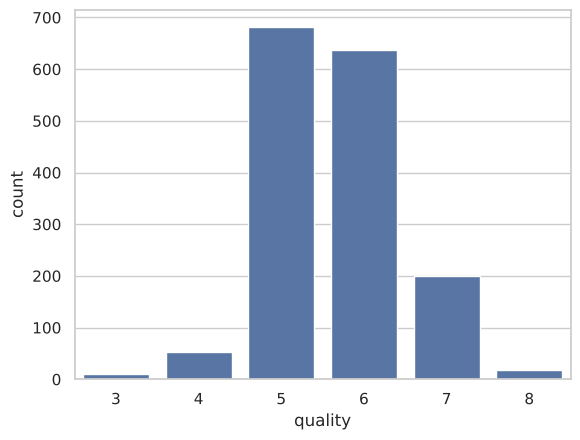

In [15]:
wine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')
print(wine.shape, " missing values:", wine.isna().sum().sum())
sns.countplot(x='quality', data=wine)
plt.show()

In [16]:
Xw = wine.drop(columns='quality')
yw = wine['quality']
Xw_train, Xw_test, yw_train, yw_test = train_test_split(Xw, yw, test_size=0.2, stratify=yw, random_state=0)
pd.DataFrame({'train': yw_train.value_counts(), 'test': yw_test.value_counts()}).sort_index()

,train,test
quality,,
3,8,2
4,42,11
5,545,136
6,510,128
7,159,40
8,15,3


`stratify=yw` keeps the class proportions the same in train and test, essential when some classes only
have a handful of examples (2 wines rated 3 in the test set). The course split had no `random_state`, so its
numbers changed every run.

## Without balancing

In [17]:
models = {
    "decision tree": DecisionTreeClassifier(random_state=0),
    "random forest": RandomForestClassifier(random_state=0, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(random_state=0),
    "gradient boosting": GradientBoostingClassifier(random_state=0),
}

def scores(clf, X, y):
    clf.fit(X, y)
    p = clf.predict(Xw_test)
    return {'accuracy': accuracy_score(yw_test, p), 'balanced acc': balanced_accuracy_score(yw_test, p),
            'macro F1': f1_score(yw_test, p, average='macro', zero_division=0)}

base = {name: scores(clf, Xw_train, yw_train) for name, clf in models.items()}
pd.DataFrame(base).T.round(3)

,accuracy,balanced acc,macro F1
decision tree,0.603,0.298,0.295
random forest,0.712,0.340,0.340
AdaBoost,0.597,0.269,0.272
gradient boosting,0.678,0.326,0.326


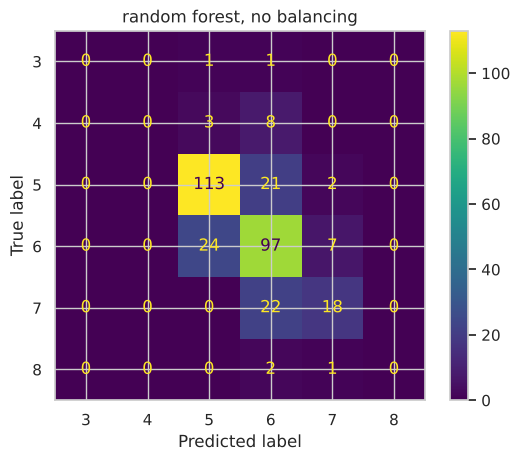

In [18]:
rf = RandomForestClassifier(random_state=0, n_jobs=-1).fit(Xw_train, yw_train)
ConfusionMatrixDisplay.from_estimator(rf, Xw_test, yw_test)
plt.title('random forest, no balancing')
plt.show()

The random forest gets about 70% accuracy, but look at the rows for 3, 4 and 8: almost nothing in those
classes is predicted correctly. Accuracy is dominated by classes 5 and 6. **Balanced accuracy** (the
average recall over classes) and **macro F1** weigh every class equally, so they show the problem.

## Resampling the training set

From `imbalanced-learn`. Only the training data is resampled. The test set keeps the real class
distribution, otherwise the evaluation means nothing.

* **Under-sampling** (remove majority samples)
  * `RandomUnderSampler`: at random
  * `NearMiss`: keeps the majority samples closest to the minority class
  * `TomekLinks`: removes majority samples that form a "Tomek link" (mutual nearest neighbours of different
    classes) with a minority sample, cleaning up the boundary
* **Over-sampling** (add minority samples)
  * `RandomOverSampler`: duplicates at random
  * `SMOTE`: creates synthetic samples on the lines between a minority sample and its minority neighbours
  * `BorderlineSMOTE`: SMOTE only for minority samples near the class boundary
  * `ADASYN`: more synthetic samples where the minority class is harder to learn
* **Combined**: `SMOTETomek`, SMOTE followed by Tomek link removal

In [19]:
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTETomek

samplers = {
    "RandomUnderSampler": RandomUnderSampler(random_state=0),
    "NearMiss": NearMiss(version=1),
    "TomekLinks": TomekLinks(),
    "RandomOverSampler": RandomOverSampler(random_state=0),
    "SMOTE": SMOTE(random_state=0),
    "BorderlineSMOTE": BorderlineSMOTE(random_state=0),
    "ADASYN (minority)": ADASYN(sampling_strategy='minority', random_state=0),
    "SMOTETomek": SMOTETomek(random_state=0),
}

resampled = {}
counts = {'none': yw_train.value_counts().sort_index()}
for name, s in samplers.items():
    Xr, yr = s.fit_resample(Xw_train, yw_train)
    resampled[name] = (Xr, yr)
    counts[name] = yr.value_counts().sort_index()
pd.DataFrame(counts).fillna(0).astype(int).T

quality,3,4,5,6,7,8
none,8,42,545,510,159,15
RandomUnderSampler,8,8,8,8,8,8
NearMiss,8,8,8,8,8,8
TomekLinks,8,24,461,408,125,9
RandomOverSampler,545,545,545,545,545,545
SMOTE,545,545,545,545,545,545
BorderlineSMOTE,545,545,545,545,545,545
ADASYN (minority),546,42,545,510,159,15
SMOTETomek,536,530,476,480,529,541


* The random under-sampler and NearMiss cut every class down to 8 wines: 48 training samples in total.
* Tomek links only removes a few hundred borderline majority samples.
* The over-samplers bring every class up to 545.
* `ADASYN(sampling_strategy='minority')` only over-samples the single smallest class (3), leaving 4 and 8
  as rare as before. The course used this setting, which explains why ADASYN behaved differently from the
  others.

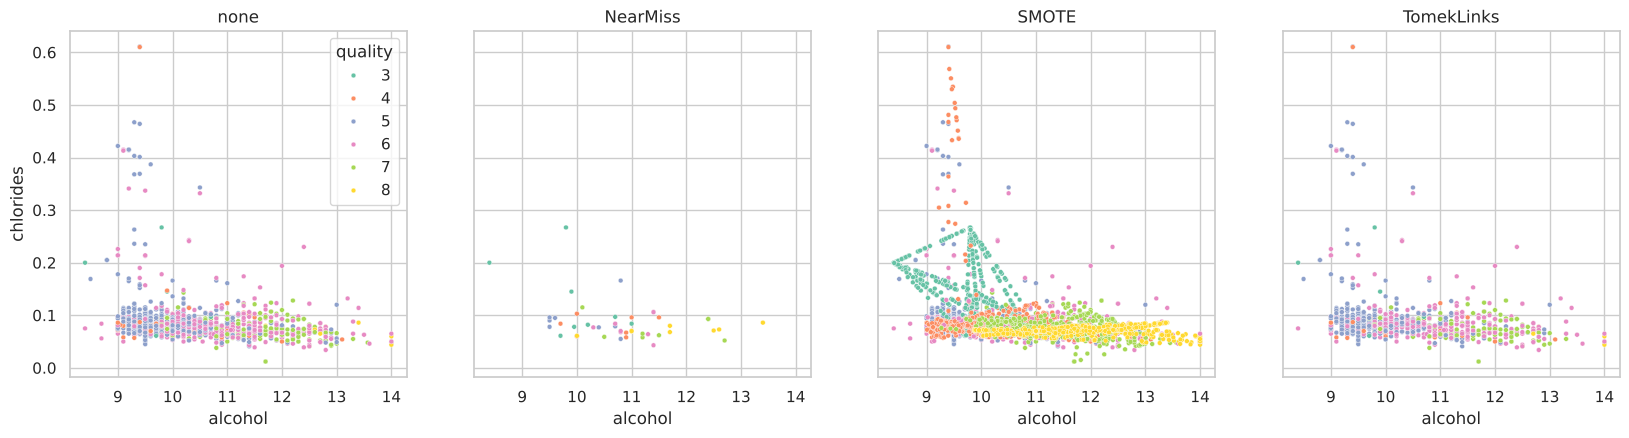

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5), sharex=True, sharey=True)
pal = sns.color_palette('Set2', 6)
for ax, (name, (Xr, yr)) in zip(axes, [('none', (Xw_train, yw_train))] +
                                [(k, resampled[k]) for k in ['NearMiss', 'SMOTE', 'TomekLinks']]):
    sns.scatterplot(x=Xr['alcohol'], y=Xr['chlorides'], hue=yr, palette=pal, s=12, ax=ax, legend=(name == 'none'))
    ax.set_title(name)
plt.show()

SMOTE's synthetic points show up as straight-line streaks between existing minority samples.

(The course's "before balancing" plot used `hue=y['quality']`, the *full* label column, with the training
features, so the colours didn't line up with the points.)

In [21]:
rows = []
for s_name, (Xr, yr) in [('none', (Xw_train, yw_train))] + list(resampled.items()):
    for m_name, clf in models.items():
        sc = scores(clf, Xr, yr)
        rows.append({'sampler': s_name, 'model': m_name, **sc})

res = pd.DataFrame(rows)
res.pivot(index='sampler', columns='model', values='macro F1').loc[['none'] + list(samplers)].round(3)

model,AdaBoost,decision tree,gradient boosting,random forest
sampler,,,,
none,0.272,0.295,0.326,0.340
RandomUnderSampler,0.158,0.165,0.166,0.181
NearMiss,0.180,0.187,0.156,0.173
TomekLinks,0.257,0.327,0.309,0.335
RandomOverSampler,0.251,0.395,0.395,0.331
SMOTE,0.272,0.346,0.308,0.364
BorderlineSMOTE,0.251,0.308,0.318,0.357
ADASYN (minority),0.261,0.378,0.309,0.338
SMOTETomek,0.228,0.290,0.295,0.382


In [22]:
res.pivot(index='sampler', columns='model', values='accuracy').loc[['none'] + list(samplers)].round(3)

model,AdaBoost,decision tree,gradient boosting,random forest
sampler,,,,
none,0.597,0.603,0.678,0.712
RandomUnderSampler,0.197,0.231,0.241,0.266
NearMiss,0.241,0.225,0.175,0.181
TomekLinks,0.544,0.625,0.656,0.706
RandomOverSampler,0.375,0.666,0.606,0.700
SMOTE,0.362,0.625,0.572,0.653
BorderlineSMOTE,0.416,0.591,0.647,0.700
ADASYN (minority),0.556,0.656,0.641,0.709
SMOTETomek,0.297,0.562,0.534,0.666


What the two tables show:

* **Random under-sampling and NearMiss are disastrous** here (accuracy below 30%). 48 training wines
  isn't enough to learn anything. Under-sampling only makes sense when even the smallest class has plenty
  of samples.
* **The over-samplers keep accuracy close to the unbalanced model** and change macro F1 by a few points in
  either direction depending on the model. With 10 and 18 examples of the rarest classes, SMOTE can only
  invent so much new information.
* **AdaBoost is the most fragile.** Its reweighting focuses on hard examples, and after resampling there are
  many duplicated or synthetic ones to chase.
* The random forest is the best or close to it in almost every row.

Accuracy and macro F1 often move in opposite directions: resampling trades some accuracy on the big classes
for better recall on the small ones. Which matters more depends on what the model is for.

With only 2-4 test samples in classes 3 and 8, these scores are noisy. One more correct prediction moves
macro F1 by several points, so small differences between rows don't mean much.

This table also compares 36 combinations on the same test set, which is a form of model selection on test
data. That's fine for exploring, but to actually pick a sampler and model the comparison should use cross
validation on the training set (as in the next section), keeping the test set for one final check.

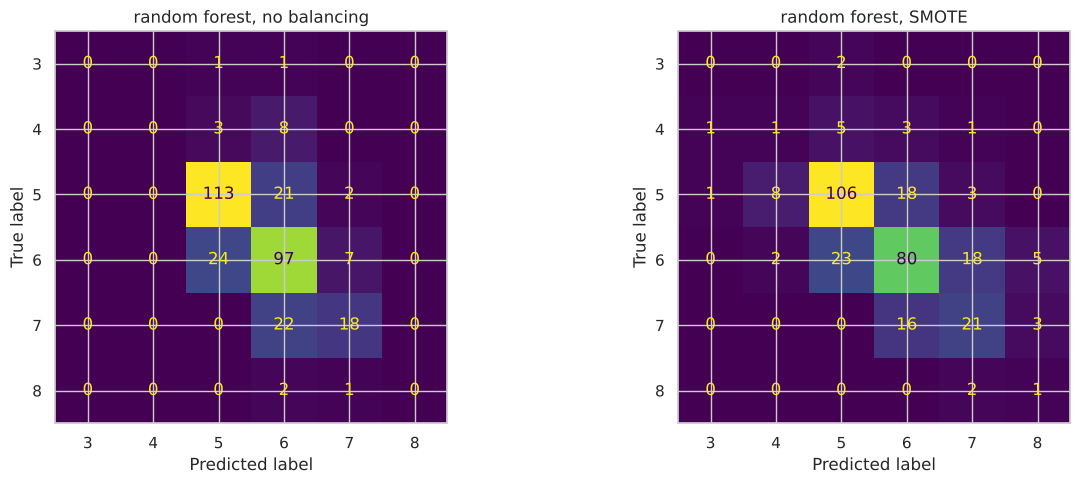

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, (Xr, yr)) in zip(axes, [('no balancing', (Xw_train, yw_train)), ('SMOTE', resampled['SMOTE'])]):
    clf = RandomForestClassifier(random_state=0, n_jobs=-1).fit(Xr, yr)
    ConfusionMatrixDisplay.from_estimator(clf, Xw_test, yw_test, ax=ax, colorbar=False)
    ax.set_title(f"random forest, {name}")
plt.tight_layout()
plt.show()

## A simpler option: class weights

Many sklearn classifiers accept `class_weight='balanced'`, which weights each sample inversely to its class
frequency during training. No new samples, nothing thrown away.

In [24]:
for name, clf in [("random forest, balanced", RandomForestClassifier(class_weight='balanced', random_state=0, n_jobs=-1)),
                  ("random forest, balanced_subsample", RandomForestClassifier(class_weight='balanced_subsample', random_state=0, n_jobs=-1)),
                  ("decision tree, balanced", DecisionTreeClassifier(class_weight='balanced', random_state=0))]:
    print(f"{name:35s}", {k: round(v, 3) for k, v in scores(clf, Xw_train, yw_train).items()})

random forest, balanced             {'accuracy': 0.691, 'balanced acc': 0.433, 'macro F1': 0.449}


random forest, balanced_subsample   {'accuracy': 0.7, 'balanced acc': 0.329, 'macro F1': 0.33}
decision tree, balanced             {'accuracy': 0.613, 'balanced acc': 0.359, 'macro F1': 0.335}


For the random forest, `class_weight='balanced'` gives the best macro F1 of anything in this notebook
(about 0.45, against 0.34 unbalanced and at most 0.40 with resampling) while keeping accuracy close to
70%. Worth trying before resampling. (`balanced_subsample`, which recomputes the weights per bootstrap
sample, did much less here.)

## Doing it properly in cross validation

If resampling is done before cross validation, synthetic points created from a validation-fold sample can
end up in the training folds, and the score is optimistic. `imblearn.pipeline.Pipeline` applies the sampler
only during `fit`, on the training folds:

In [25]:
from imblearn.pipeline import Pipeline as ImbPipeline

for name, pipe in [("no resampling", ImbPipeline([('clf', RandomForestClassifier(random_state=0, n_jobs=-1))])),
                   ("SMOTE in pipeline", ImbPipeline([('smote', SMOTE(random_state=0, k_neighbors=3)),
                                                      ('clf', RandomForestClassifier(random_state=0, n_jobs=-1))]))]:
    cv = cross_val_score(pipe, Xw_train, yw_train, scoring='f1_macro',
                         cv=StratifiedKFold(5, shuffle=True, random_state=0))
    print(f"{name:20s} CV macro F1 {cv.mean():.3f} +/- {cv.std():.3f}")

no resampling        CV macro F1 0.362 +/- 0.040


SMOTE in pipeline    CV macro F1 0.349 +/- 0.034


(`k_neighbors=3` because some folds have only 6 wines rated 3, and SMOTE needs at least `k_neighbors + 1`
samples of a class.)

In cross validation SMOTE doesn't help this random forest at all, the difference is well within the
spread between folds.

## Summary

* bagging and random forests turn an overfitting tree into a strong classifier. Boosting (hist gradient
  boosting, XGBoost) is usually the most accurate, AdaBoost with stumps is weak on complex problems
* tune inside a pipeline, compare with cross validation, and keep a simple baseline in the table
* for imbalanced classes, look at balanced accuracy / macro F1 and the confusion matrix, not just accuracy
* resample only the training data (in CV: inside an `imblearn` pipeline), try `class_weight='balanced'`
  first, and don't under-sample when the minority classes are tiny